###1. Setup and Data Acquisition

This section handles the necessary imports and downloads the Human Activity Recognition (HAR) dataset directly from the UCI Machine Learning Repository.




In [4]:
import io
import time
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

def load_data():
    """Downloads and extracts the nested UCI HAR dataset."""
    url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
    print("Downloading UCI HAR dataset...")

    response = requests.get(url, timeout=120)
    response.raise_for_status()
    print("Download completed. Extracting nested archive...")

    # The downloaded ZIP contains ANOTHER ZIP file named 'UCI HAR Dataset.zip'
    with zipfile.ZipFile(io.BytesIO(response.content)) as outer_zip:
        with outer_zip.open("UCI HAR Dataset.zip") as inner_zip_file:
            with zipfile.ZipFile(io.BytesIO(inner_zip_file.read())) as inner_zip:

                # Read training data
                with inner_zip.open("UCI HAR Dataset/train/X_train.txt") as f:
                    X_train_original = pd.read_csv(f, sep=r"\s+", header=None)
                with inner_zip.open("UCI HAR Dataset/train/y_train.txt") as f:
                    y_train_original = pd.read_csv(f, sep=r"\s+", header=None)

                # Read official test data
                with inner_zip.open("UCI HAR Dataset/test/X_test.txt") as f:
                    X_test_original = pd.read_csv(f, sep=r"\s+", header=None)
                with inner_zip.open("UCI HAR Dataset/test/y_test.txt") as f:
                    y_test_original = pd.read_csv(f, sep=r"\s+", header=None)

    # Combine official train/test sets to create our own splits later
    X = pd.concat([X_train_original, X_test_original], ignore_index=True)
    y = pd.concat([y_train_original, y_test_original], ignore_index=True).values.ravel()

    return X, y

###2. Data Preprocessing
Here, the dataset is loaded, labels are encoded, and the data is split and scaled. Crucially, the scaler is only fitted on the training data to prevent data leakage.

In [5]:
print("\n" + "=" * 70)
print("LOADING & PREPROCESSING DATASET")
print("=" * 70)

X, y = load_data()

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train/Test Split (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)


LOADING & PREPROCESSING DATASET
Download completed. Extracting nested archive...
Dataset shape: (10299, 561)
Number of features: 561
Scaled training shape: (8239, 561)
Scaled testing shape: (2060, 561)


###3. Baseline Model Evaluation
We establish a performance baseline by training a Gaussian Naive Bayes classifier on all 561 original features, recording both accuracy and wall-clock training time.

In [6]:
print("\n" + "=" * 70)
print("BASELINE: GAUSSIAN NAIVE BAYES WITH 561 FEATURES")
print("=" * 70)

start_time = time.perf_counter()

baseline_model = GaussianNB()
baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)

baseline_time = time.perf_counter() - start_time
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy : {baseline_accuracy:.4f}")
print(f"Baseline Time     : {baseline_time:.6f} seconds")
print(f"Number of Features: {X_train_scaled.shape[1]}")


BASELINE: GAUSSIAN NAIVE BAYES WITH 561 FEATURES
Baseline Accuracy : 0.7549
Baseline Time     : 0.162561 seconds
Number of Features: 561


###4. K-Means Feature Selection Experiment
This loop transposes the dataset to cluster the features rather than the data points. For each cluster size, it extracts the feature closest to the mathematical centroid to act as the representative variable.

In [7]:
print("\n" + "=" * 70)
print("K-MEANS FEATURE SELECTION EXPERIMENT")
print("=" * 70)

clusters_to_test = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
accuracies, training_times, feature_selection_times = [], [], []

# Transpose matrix: Features become rows, samples become columns
feature_matrix = X_train_scaled.T

for k in clusters_to_test:
    selection_start = time.perf_counter()

    # Cluster the features
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(feature_matrix)

    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    # Select the feature closest to each cluster centroid
    selected_indices = []
    for cluster_id in range(k):
        cluster_feature_indices = np.where(labels == cluster_id)[0]
        cluster_features = feature_matrix[cluster_feature_indices]
        centroid = centers[cluster_id]

        # Calculate squared Euclidean distance to centroid
        distances = np.sum((cluster_features - centroid) ** 2, axis=1)
        closest_feature_position = np.argmin(distances)
        representative_feature = cluster_feature_indices[closest_feature_position]

        selected_indices.append(representative_feature)

    selected_indices = np.array(selected_indices, dtype=int)
    feature_selection_time = time.perf_counter() - selection_start

    # Filter training and testing sets to only include selected features
    X_train_reduced = X_train_scaled[:, selected_indices]
    X_test_reduced = X_test_scaled[:, selected_indices]

    # Train reduced model
    training_start = time.perf_counter()
    reduced_model = GaussianNB()
    reduced_model.fit(X_train_reduced, y_train)
    y_pred_reduced = reduced_model.predict(X_test_reduced)
    training_time = time.perf_counter() - training_start

    # Store metrics
    accuracy = accuracy_score(y_test, y_pred_reduced)
    accuracies.append(accuracy)
    training_times.append(training_time)
    feature_selection_times.append(feature_selection_time)

    print(f"Clusters: {k:3d} | Features: {X_train_reduced.shape[1]:3d} | "
          f"Accuracy: {accuracy:.4f} | Training: {training_time:.6f}s")


K-MEANS FEATURE SELECTION EXPERIMENT
Clusters:  10 | Features:  10 | Accuracy: 0.7646 | Training: 0.004561s
Clusters:  20 | Features:  20 | Accuracy: 0.8068 | Training: 0.006000s
Clusters:  30 | Features:  30 | Accuracy: 0.8325 | Training: 0.010348s
Clusters:  40 | Features:  40 | Accuracy: 0.8408 | Training: 0.008889s
Clusters:  50 | Features:  50 | Accuracy: 0.8578 | Training: 0.015862s
Clusters:  60 | Features:  60 | Accuracy: 0.8354 | Training: 0.023256s
Clusters:  70 | Features:  70 | Accuracy: 0.8340 | Training: 0.071698s
Clusters:  80 | Features:  80 | Accuracy: 0.8587 | Training: 0.025606s
Clusters:  90 | Features:  90 | Accuracy: 0.8621 | Training: 0.031472s
Clusters: 100 | Features: 100 | Accuracy: 0.8689 | Training: 0.022930s


###5. Results Analysis & Best Model Selection
We compile the tracked metrics into a Pandas DataFrame to identify the optimal number of clusters that maximizes accuracy while minimizing computational load.

In [8]:
print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)

results = pd.DataFrame({
    "Features": clusters_to_test,
    "Accuracy": accuracies,
    "Training_Time_sec": training_times,
    "KMeans_Selection_Time_sec": feature_selection_times
})

results["Accuracy_Improvement_vs_Baseline"] = results["Accuracy"] - baseline_accuracy
results["Accuracy_Improvement_Percentage"] = ((results["Accuracy"] - baseline_accuracy) / baseline_accuracy) * 100
results["Speedup_vs_Baseline"] = baseline_time / results["Training_Time_sec"]

print(results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# Identify best performing model
best_index = results["Accuracy"].idxmax()
best_features = int(results.loc[best_index, "Features"])
best_accuracy = results.loc[best_index, "Accuracy"]
best_training_time = results.loc[best_index, "Training_Time_sec"]

print("\n" + "=" * 70)
print("BEST K-MEANS MODEL SUMMARY")
print("=" * 70)
print(f"Optimal Features     : {best_features}")
print(f"Best Accuracy        : {best_accuracy:.4f}")
print(f"Accuracy Difference  : {best_accuracy - baseline_accuracy:+.4f}")
print(f"Training Speedup     : {baseline_time / best_training_time:.2f}x")


FINAL RESULTS
 Features  Accuracy  Training_Time_sec  KMeans_Selection_Time_sec  Accuracy_Improvement_vs_Baseline  Accuracy_Improvement_Percentage  Speedup_vs_Baseline
       10  0.764563           0.004561                   5.168755                          0.009709                         1.286174            35.643148
       20  0.806796           0.006000                   4.376228                          0.051942                         6.881029            27.091925
       30  0.832524           0.010348                   5.391324                          0.077670                        10.289389            15.708763
       40  0.840777           0.008889                   9.012217                          0.085922                        11.382637            18.287462
       50  0.857767           0.015862                  11.254282                          0.102913                        13.633441            10.248188
       60  0.835437           0.023256                  12.58

###6. Visualizations & Data Export
Finally, we generate publication-ready matplotlib charts comparing the baseline performance against the K-Means reduced pipelines, and export the raw data.

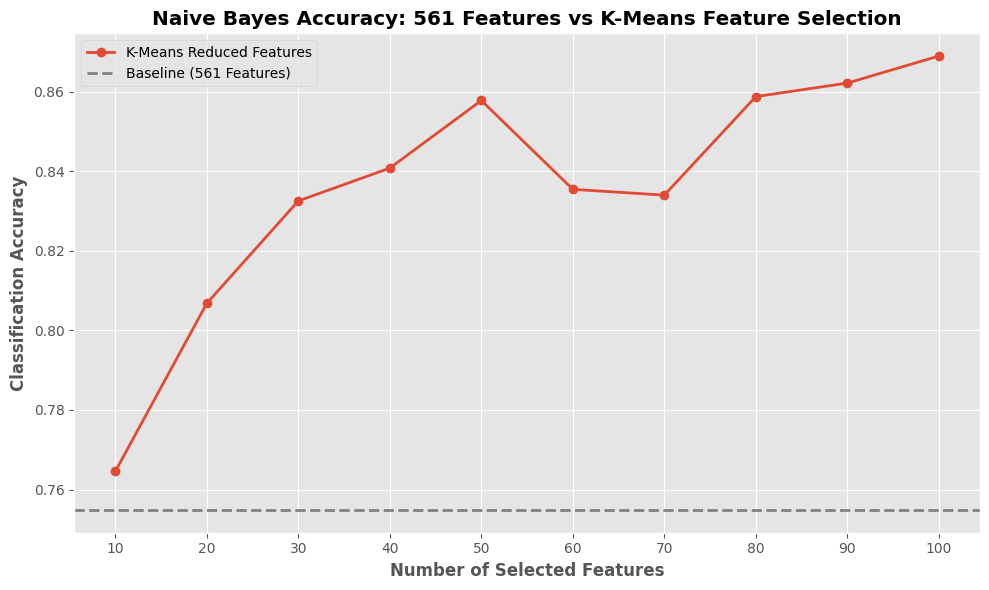

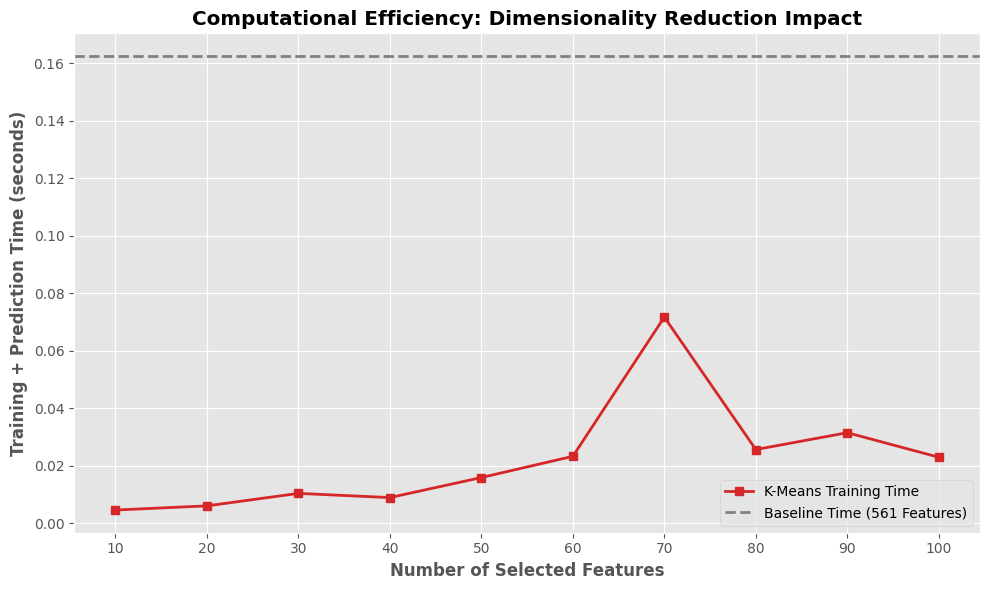


Results successfully exported to 'kmeans_naive_bayes_results.csv'


In [9]:
plt.style.use('ggplot')

# Plot 1: Accuracy Comparison
plt.figure(figsize=(10, 6))
plt.plot(clusters_to_test, accuracies, marker="o", linewidth=2, label="K-Means Reduced Features")
plt.axhline(y=baseline_accuracy, linestyle="--", color="gray", linewidth=2, label="Baseline (561 Features)")
plt.xlabel("Number of Selected Features", fontweight='bold')
plt.ylabel("Classification Accuracy", fontweight='bold')
plt.title("Naive Bayes Accuracy: 561 Features vs K-Means Feature Selection", fontweight='bold')
plt.xticks(clusters_to_test)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Training Time Comparison
plt.figure(figsize=(10, 6))
plt.plot(clusters_to_test, training_times, marker="s", color="tab:red", linewidth=2, label="K-Means Training Time")
plt.axhline(y=baseline_time, linestyle="--", color="gray", linewidth=2, label="Baseline Time (561 Features)")
plt.xlabel("Number of Selected Features", fontweight='bold')
plt.ylabel("Training + Prediction Time (seconds)", fontweight='bold')
plt.title("Computational Efficiency: Dimensionality Reduction Impact", fontweight='bold')
plt.xticks(clusters_to_test)
plt.legend()
plt.tight_layout()
plt.show()

# Export Results
results.to_csv("kmeans_naive_bayes_results.csv", index=False)
print("\nResults successfully exported to 'kmeans_naive_bayes_results.csv'")